In [1]:
from typing import TypedDict, Literal

class PortfolioState(TypedDict):
    totalAmt: float
    totalUSD: float
    targetCurr: Literal["INR", "EUR"]
    total: float

In [3]:
def calcTotalUSD(state: PortfolioState) -> PortfolioState:
    state["totalUSD"] = state["totalAmt"] * 1.08
    return state

def calcTotalINR(state: PortfolioState) -> PortfolioState:
    state["total"] = state["totalUSD"] * 85
    return state

def calcTotalEUR(state: PortfolioState) -> PortfolioState:
    state["total"] = state["totalUSD"] * 0.9
    return state

def chooseConversion(state: PortfolioState) -> str:
    return state["targetCurr"]

In [5]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node("calcTotalUSD_node",calcTotalUSD)
builder.add_node("calcTotalINR_node",calcTotalINR)
builder.add_node("calcTotalEUR_node",calcTotalEUR)


builder.add_edge(START, "calcTotalUSD_node")
builder.add_conditional_edges("calcTotalUSD_node",
                              chooseConversion,
                              {
                                  "INR": "calcTotalINR_node",
                                  "EUR": "calcTotalEUR_node"
                              })
builder.add_edge(["calcTotalINR_node", "calcTotalEUR_node"],END)

graph = builder.compile()

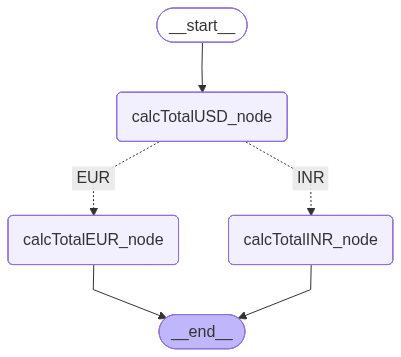

In [6]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
graph.invoke({"totalAmt":1000, "targetCurr":"INR"})

{'totalAmt': 1000, 'totalUSD': 1080.0, 'targetCurr': 'INR', 'total': 91800.0}

In [8]:
graph.invoke({"totalAmt":1000, "targetCurr":"EUR"})

{'totalAmt': 1000, 'totalUSD': 1080.0, 'targetCurr': 'EUR', 'total': 972.0}

In [9]:
graph.invoke({"totalUSD": 2000, "targetCurr":"INR"})

KeyError: 'totalAmt'